# Entrenamiento de modelo SVM
Notebook dedicado al entrenamiento, ajuste y evaluación de un modelo SVM usando pipeline y GridSearchCV.

In [ ]:
# Importar librerías necesarias
from sklearn.base import clone
from sklearn.ensemble import BaggingClassifier
from sklearn.inspection import permutation_importance
import joblib


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate
)

from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)

import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import make_scorer, fbeta_score

## 1. Cargar y explorar los datos
Cargamos los datos procesados y revisamos sus dimensiones y balance de clases.

X_train: (3065, 13)
y_train: (3065,)
X_val: (2044, 13)
y_val: (2044,)


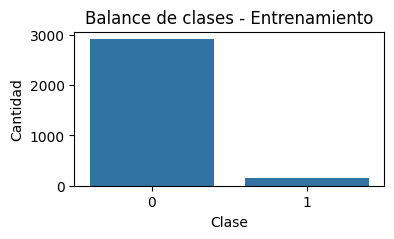

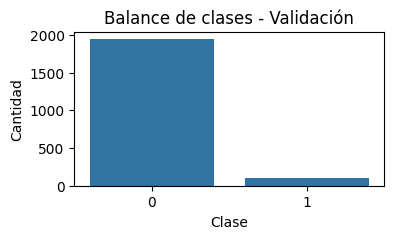

In [6]:
# Cargar datos procesados (usando joblib)
data = joblib.load('../data/processed_data.pkl')
X_train = data['X_train']
X_val = data['X_val']
y_train = data['y_train']
y_val = data['y_val']

print('X_train:', X_train.shape)
print('y_train:', y_train.shape)
print('X_val:', X_val.shape)
print('y_val:', y_val.shape)

# Balance de clases
def plot_class_balance(y, title):
    plt.figure(figsize=(4,2))
    sns.countplot(x=y)
    plt.title(title)
    plt.xlabel('Clase')
    plt.ylabel('Cantidad')
    plt.show()

plot_class_balance(y_train, 'Balance de clases - Entrenamiento')
plot_class_balance(y_val, 'Balance de clases - Validación')

In [7]:
# Revisar tipos de datos y primeras filas
print(X_train.dtypes.head(10))
display(X_train.head())

age                       float64
avg_glucose_level         float64
bmi                       float64
hypertension                int64
heart_disease               int64
gender                      int64
ever_married                int64
Residence_type              int64
work_type_Never_worked      int32
work_type_Private           int32
dtype: object


,age,avg_glucose_level,bmi,hypertension,heart_disease,gender,ever_married,Residence_type,work_type_Never_worked,work_type_Private,work_type_Self-employed,smoking_status_never smoked,smoking_status_smokes
3135,44.0,84.10,30.2,1,0,0,1,0,0,1,0,1,0
3455,75.0,223.14,27.8,0,0,0,1,1,0,0,0,1,0
1438,47.0,93.55,31.4,0,0,0,1,0,0,1,0,1,0
1566,76.0,101.43,29.1,0,1,0,1,0,0,0,1,1,0
4182,28.0,104.16,21.5,0,0,1,0,0,0,1,0,1,0


## 2. Pipeline y búsqueda de hiperparámetros
Definimos un pipeline con escalado y SVM, y buscamos los mejores hiperparámetros con GridSearchCV usando validación cruzada estratificada y múltiples métricas.

In [ ]:

# ------------------------------------------------------------
# 1. Métrica principal: F4-score
# Beta = 4 => Recall pesa mucho más que Precision
# ------------------------------------------------------------
f4_scorer = make_scorer(fbeta_score, beta=4)

# ------------------------------------------------------------
# 2. Validación cruzada estratificada
# ------------------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ------------------------------------------------------------
# 3. Pipeline base
# ------------------------------------------------------------
pipeline = Pipeline([
    ('model', SVC(
        random_state=42,
        probability=True,
        class_weight='balanced'
    ))
])

# ------------------------------------------------------------
# 4. Espacio de búsqueda combinado
# Incluye búsqueda inicial + búsqueda fina, todo junto
# ------------------------------------------------------------
param_distributions = [
    # Kernel lineal
    {
        "model__kernel": ["linear"],
        "model__C": np.unique(np.concatenate([
            [0.01, 0.1, 1, 10, 100],
            np.logspace(-3, 2, 7)
        ]))
    },
    
    # Kernel RBF
    {
        "model__kernel": ["rbf"],
        "model__C": np.unique(np.concatenate([
            [0.1, 1, 10, 100],
            np.logspace(-2, 2, 7)
        ])),
        "model__gamma": ["scale", "auto", 0.001, 0.005, 0.01, 0.05, 0.1]
    },
    
    # Kernel polinómico
    {
        "model__kernel": ["poly"],
        "model__C": [0.1, 1, 10],
        "model__degree": [2, 3, 4],
        "model__gamma": ["scale", "auto"]
    },
    
    # Kernel sigmoide
    {
        "model__kernel": ["sigmoid"],
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", "auto"]
    }
]

# ------------------------------------------------------------
# 5. Métricas de evaluación
# F4 es la métrica principal para seleccionar el mejor modelo
# ------------------------------------------------------------
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "f4": f4_scorer,
    "roc_auc": "roc_auc",
    "ap": "average_precision"
}

# ------------------------------------------------------------
# 6. Parámetros comunes del RandomizedSearchCV
# ------------------------------------------------------------
search_kwargs = dict(
    n_iter=30,                 # 30 combinaciones aleatorias
    scoring=scoring,
    refit="f4",                # refit según F4-score
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    return_train_score=False,
)

# ------------------------------------------------------------
# 7. Búsqueda aleatoria
# ------------------------------------------------------------
random_search_svm = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    **search_kwargs
)

random_search_svm.fit(X_train, y_train)


In [ ]:

# ------------------------------------------------------------
# 8. Resultados principales
# ------------------------------------------------------------
print("Mejores hiperparámetros:")
print(random_search_svm.best_params_)

print("\nMejor F4-score promedio en CV:")
print(f"{random_search_svm.best_score_:.4f}")

# ------------------------------------------------------------
# 9. Tabla resumen de resultados
# ------------------------------------------------------------
results_svm = pd.DataFrame(random_search_svm.cv_results_)

cols_to_show = [
    "params",
    "mean_test_accuracy",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1",
    "mean_test_f4",
    "mean_test_roc_auc",
    "mean_test_ap",
    "rank_test_f4"
]

summary_svm = (
    results_svm[cols_to_show]
    .sort_values("rank_test_f4")
    .reset_index(drop=True)
)

print("\nTop 10 configuraciones según F4-score:")
display(summary_svm.head(10))

# ------------------------------------------------------------
# 10. Mejor modelo final
# ------------------------------------------------------------
best_svm_model = random_search_svm.best_estimator_

In [ ]:

# ------------------------------------------------------------
# 2. Bagging sobre el mejor SVM encontrado
# ------------------------------------------------------------
# best_svm_model debe venir de la celda anterior:
# best_svm_model = random_search_svm.best_estimator_

bagging_svm = BaggingClassifier(
    estimator=clone(best_svm_model),
    n_estimators=15,
    max_samples=0.8,
    max_features=1.0,
    bootstrap=True,
    bootstrap_features=False,
    n_jobs=-1,
    random_state=42
)

bagging_svm.fit(X_train, y_train)

# ------------------------------------------------------------
# 3. Evaluación en validación
# ------------------------------------------------------------
val_preds_bagging = bagging_svm.predict(X_val)
val_proba_bagging = bagging_svm.predict_proba(X_val)[:, 1]

f4_val_bagging = fbeta_score(y_val, val_preds_bagging, beta=4)

metrics_bagging = {
    "Accuracy": accuracy_score(y_val, val_preds_bagging),
    "Precision": precision_score(y_val, val_preds_bagging, zero_division=0),
    "Recall": recall_score(y_val, val_preds_bagging, zero_division=0),
    "F1-score": f1_score(y_val, val_preds_bagging, zero_division=0),
    "F4-score": f4_val_bagging,
    "ROC-AUC": roc_auc_score(y_val, val_proba_bagging),
    "Average Precision": average_precision_score(y_val, val_proba_bagging)
}

print("=== VALIDACIÓN | BAGGING + SVM ===")
for metric_name, metric_value in metrics_bagging.items():
    print(f"{metric_name:<18}: {metric_value:.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_val, val_preds_bagging, digits=4, zero_division=0))

# ------------------------------------------------------------
# 4. Matriz de confusión
# ------------------------------------------------------------
cm_bagging = confusion_matrix(y_val, val_preds_bagging)
cm_bagging_norm = cm_bagging.astype("float") / cm_bagging.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_bagging, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - Bagging + SVM")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(cm_bagging_norm, annot=True, fmt=".2f", cmap="Blues")
plt.title("Matriz de confusión normalizada - Bagging + SVM")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

# ------------------------------------------------------------
# 5. Curva ROC
# ------------------------------------------------------------
fpr_bagging, tpr_bagging, _ = roc_curve(y_val, val_proba_bagging)
roc_auc_bagging = roc_auc_score(y_val, val_proba_bagging)

plt.figure(figsize=(7, 5))
plt.plot(fpr_bagging, tpr_bagging, linewidth=2, label=f"Bagging + SVM (AUC = {roc_auc_bagging:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Bagging + SVM")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 6. Curva Precision-Recall
# ------------------------------------------------------------
precision_bagging, recall_bagging, _ = precision_recall_curve(y_val, val_proba_bagging)
ap_bagging = average_precision_score(y_val, val_proba_bagging)

plt.figure(figsize=(7, 5))
plt.plot(recall_bagging, precision_bagging, linewidth=2, label=f"Bagging + SVM (AP = {ap_bagging:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Bagging + SVM")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 7. Comparación: SVM individual vs Bagging + SVM
# ------------------------------------------------------------
val_preds_svm = best_svm_model.predict(X_val)
val_proba_svm = best_svm_model.predict_proba(X_val)[:, 1]

comparison_df = pd.DataFrame([
    {
        "Modelo": "SVM individual",
        "Accuracy": accuracy_score(y_val, val_preds_svm),
        "Precision": precision_score(y_val, val_preds_svm, zero_division=0),
        "Recall": recall_score(y_val, val_preds_svm, zero_division=0),
        "F1-score": f1_score(y_val, val_preds_svm, zero_division=0),
        "F4-score": fbeta_score(y_val, val_preds_svm, beta=4),
        "ROC-AUC": roc_auc_score(y_val, val_proba_svm),
        "Average Precision": average_precision_score(y_val, val_proba_svm)
    },
    {
        "Modelo": "Bagging + SVM",
        "Accuracy": accuracy_score(y_val, val_preds_bagging),
        "Precision": precision_score(y_val, val_preds_bagging, zero_division=0),
        "Recall": recall_score(y_val, val_preds_bagging, zero_division=0),
        "F1-score": f1_score(y_val, val_preds_bagging, zero_division=0),
        "F4-score": fbeta_score(y_val, val_preds_bagging, beta=4),
        "ROC-AUC": roc_auc_score(y_val, val_proba_bagging),
        "Average Precision": average_precision_score(y_val, val_proba_bagging)
    }
])

print("\n=== Comparación de modelos ===")
display(
    comparison_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "F4-score": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "Average Precision": "{:.4f}",
    })
)

# ------------------------------------------------------------
# 8. Influencia de features con Permutation Importance
# ------------------------------------------------------------
# Esto mide cuánto cae el rendimiento (F4) al permutar cada feature.
# Es adecuado incluso si el SVM usa kernels no lineales.

perm_result = permutation_importance(
    estimator=bagging_svm,
    X=X_val,
    y=y_val,
    scoring=f4_scorer,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

# Obtener nombres de variables
if hasattr(X_train, "columns"):
    feature_names = X_train.columns
else:
    feature_names = [f"feature_{i}" for i in range(X_train.shape[1])]

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

print("\n=== Tabla de influencia de features (Permutation Importance sobre F4) ===")
display(feature_importance_df)

# ------------------------------------------------------------
# 9. Gráfico de importancia de variables
# ------------------------------------------------------------
top_n = min(15, len(feature_importance_df))
top_features = feature_importance_df.head(top_n).sort_values("importance_mean", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(top_features["feature"], top_features["importance_mean"], xerr=top_features["importance_std"])
plt.xlabel("Caída media en F4-score al permutar la variable")
plt.ylabel("Feature")
plt.title(f"Top {top_n} features más influyentes - Bagging + SVM")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 10. Guardar objetos útiles
# ------------------------------------------------------------
best_bagging_svm_model = bagging_svm
feature_importance_bagging_svm = feature_importance_df